Importing dependencies

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

Reading dataset

In [5]:
df = pd.read_csv(r"C:\Data Science Project\notebook\data\students.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.shape

(1000, 8)

In [9]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [12]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [13]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [26]:
print("Categories")
print("---------------------------------------------------------")
print("GENDER ",end=" ")
print(df['gender'].unique())
print("---------------------------------------------------------")
print("RACE ETHINICITY",end=" ")
print(df['race_ethnicity'].unique())
print("---------------------------------------------------------")
print("PARENTAL LEVEL OF EDUCATION",end=" ")
print(df['parental_level_of_education'].unique())
print("---------------------------------------------------------")
print("PARENTAL LEVEL OF EDUCATION",end=" ")
print(df['parental_level_of_education'].unique())
print("---------------------------------------------------------")
print("LUNCH",end=" ")
print(df['lunch'].unique())
print("---------------------------------------------------------")
print("TEST SEPARATION COURSE",end=" ")
print(df['test_preparation_course'].unique())
print("---------------------------------------------------------")



Categories
---------------------------------------------------------
GENDER  <StringArray>
['female', 'male']
Length: 2, dtype: str
---------------------------------------------------------
RACE ETHINICITY <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
---------------------------------------------------------
PARENTAL LEVEL OF EDUCATION <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
---------------------------------------------------------
PARENTAL LEVEL OF EDUCATION <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
---------------------------------------------------------
LUNCH <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
---------------------------------------------------------
TES

In [ ]:
categorical_features = [feature for feature in df.columns if df[feature].dtype != 'int64']
print(f"Categorical Features {numerical_features}")

numerical_features = [feature for feature in df.columns if df[feature].dtype == 'int64']
print(f"Numerical Features {categorical_features}")


Numerical Features ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']
Categorical Features ['math_score', 'reading_score', 'writing_score']


In [32]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["avg_score"] = df["total_score"]/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,avg_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [36]:
reading_full = df[df['reading_score'] == 100]['avg_score'].count()
writing_full = df[df['writing_score'] == 100]['avg_score'].count()
math_full = df[df['math_score'] == 100]['avg_score'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


Histogram

<Axes: xlabel='avg_score', ylabel='Count'>

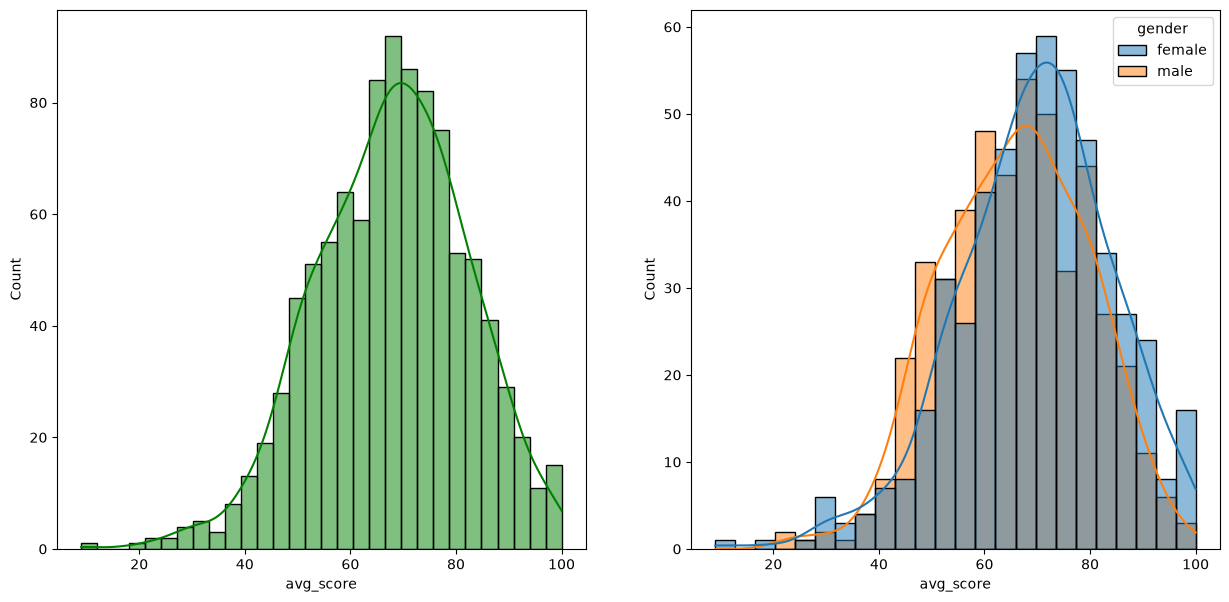

In [43]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x="avg_score",bins=30,kde=True,color="g")
plt.subplot(122)
sns.histplot(data=df,x="avg_score",kde=True,hue="gender")

<Axes: xlabel='total_score', ylabel='Count'>

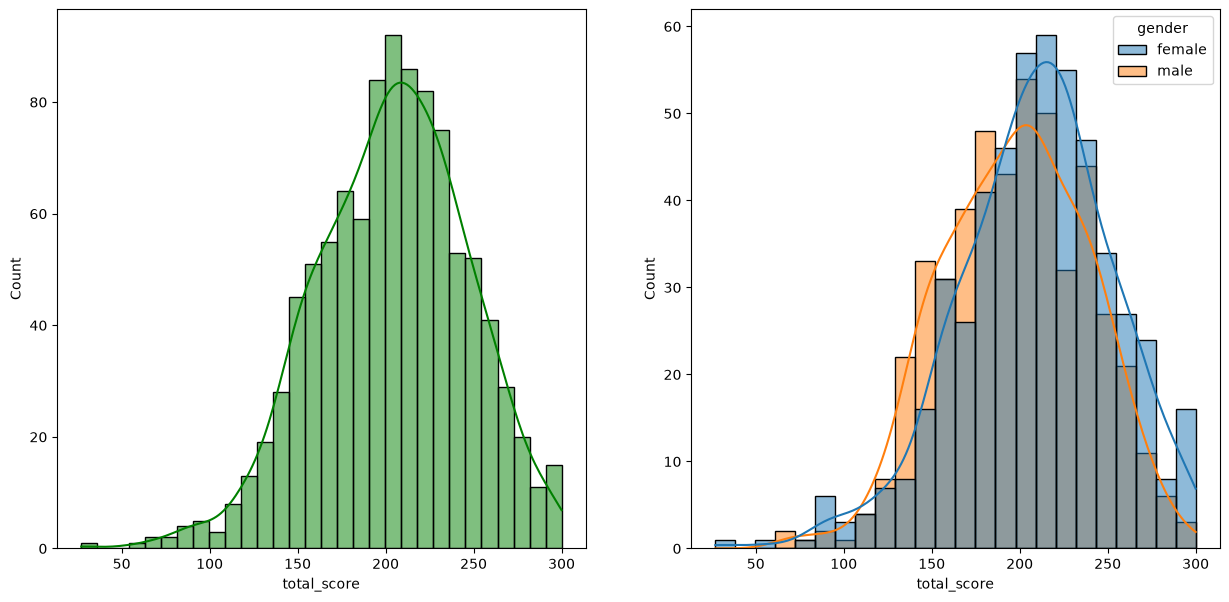

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x="total_score",bins=30,kde=True,color="g")
plt.subplot(122)
sns.histplot(data=df,x="total_score",kde=True,hue="gender")

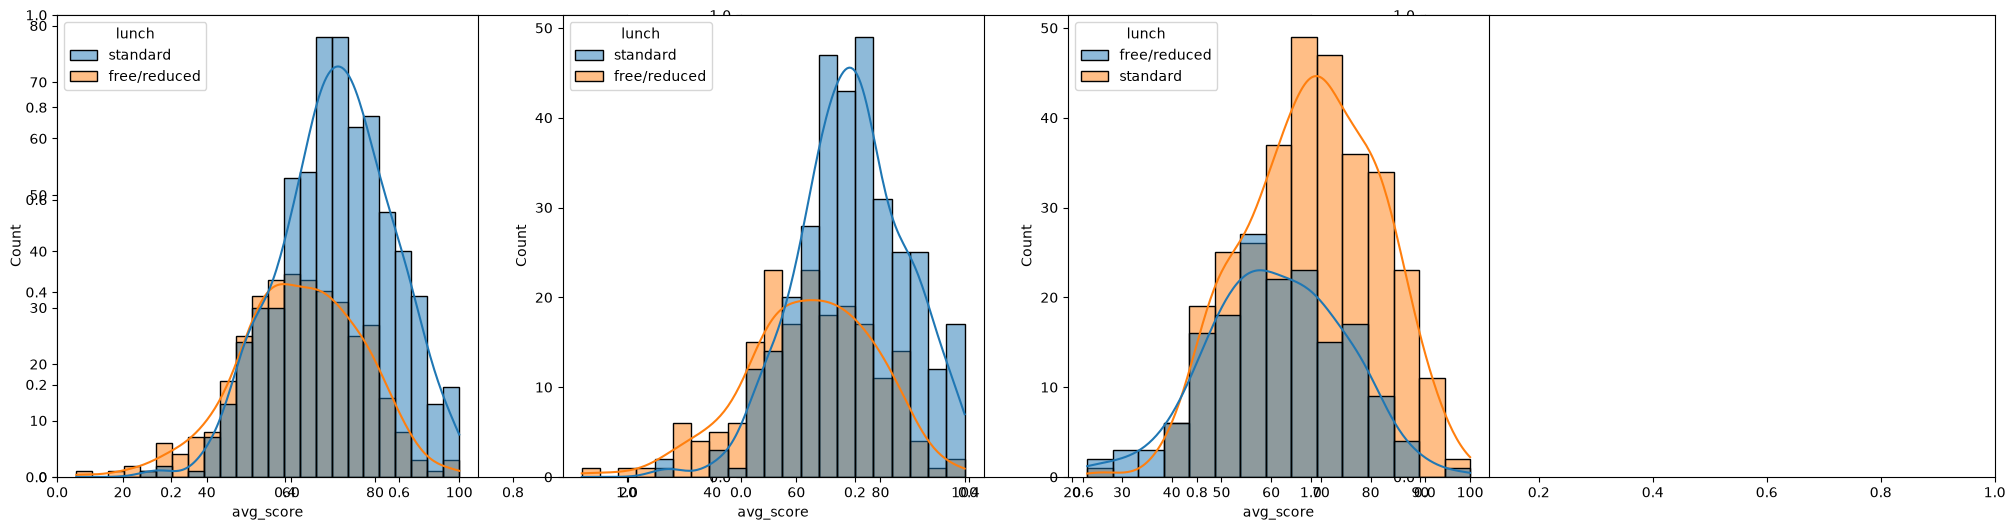

In [46]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='avg_score',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='avg_score',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='avg_score',kde=True,hue='lunch')
plt.show()

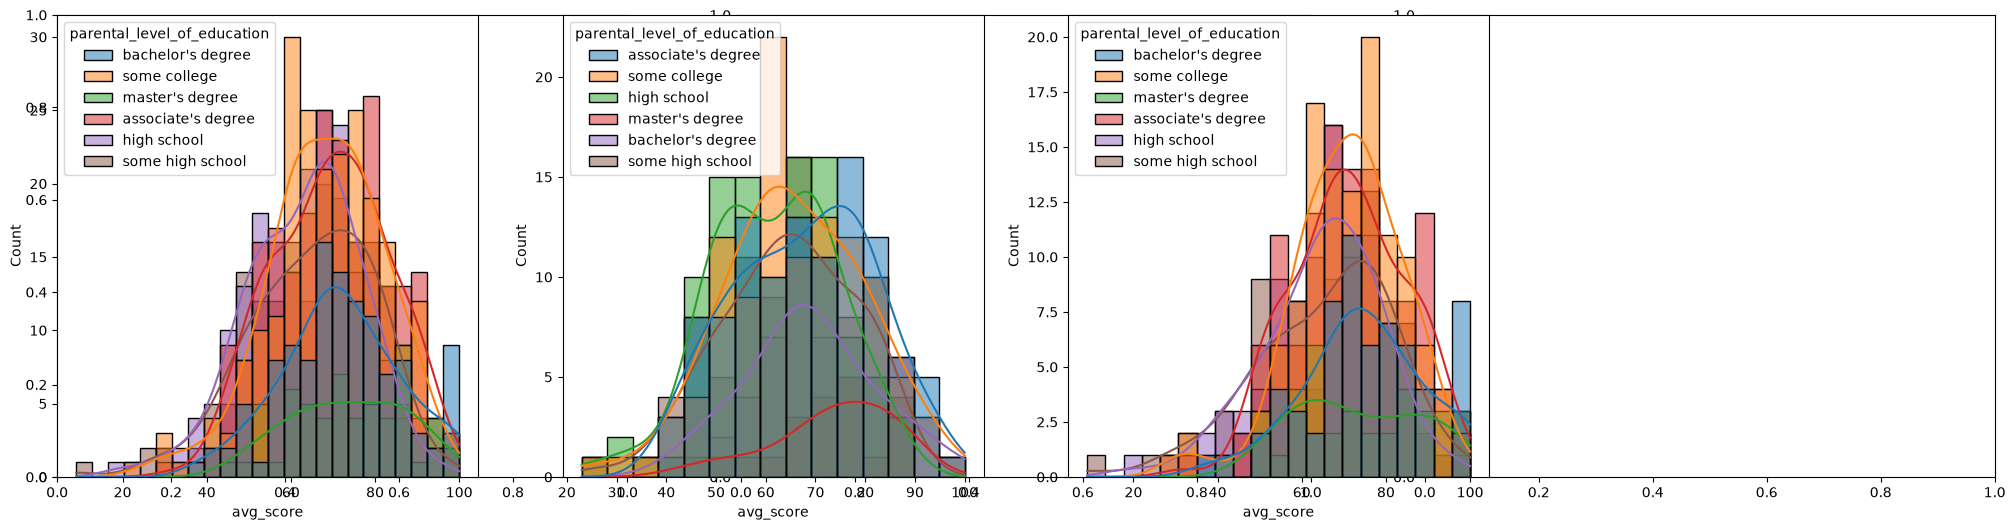

In [49]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='avg_score',kde=True,hue='parental_level_of_education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='avg_score',kde=True,hue='parental_level_of_education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='avg_score',kde=True,hue='parental_level_of_education')
plt.show()

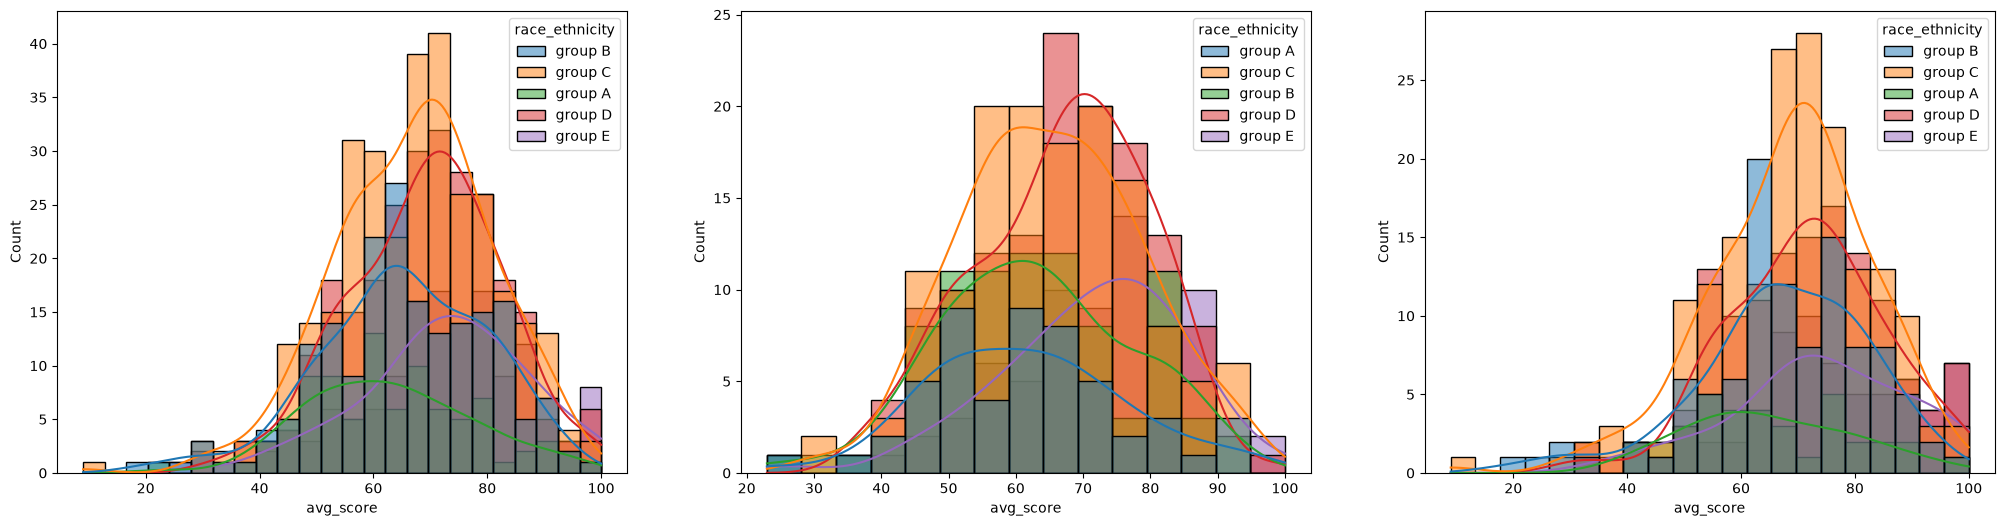

In [55]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax =sns.histplot(data=df,x='avg_score',kde=True,hue='race_ethnicity')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='male'],x='avg_score',kde=True,hue='race_ethnicity')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='female'],x='avg_score',kde=True,hue='race_ethnicity')
plt.show()

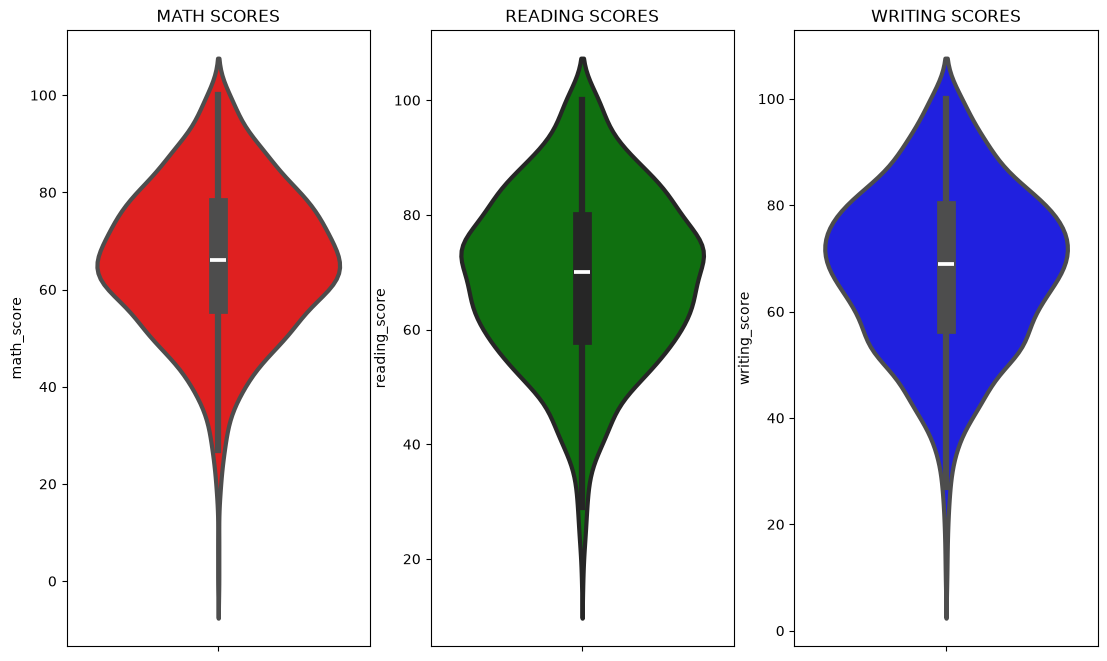

In [52]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()